# 03 — Sentiment and hedging: validation, not just scoring

`affect_report.md` (Phase 4) reports VADER-vs-transformer sign agreement per
PM (74.0%-78.9%) as a single percentage and never inspects what the
disagreements actually look like. It also flags, in a code comment in
`affect.py`, a counter-intuitive finding — PMQs hedges *less* than other
debates on the custom lexicon — without digging into why. This notebook does
both: reads the actual disagreement cases, and spot-checks the hedging
lexicon against real text rather than trusting the rate alone.

Loads the precomputed `pm_contributions_affect.parquet` directly rather than
re-scoring with `sentiment.py`/`hedging.py` — re-running the transformer over
10,673 contributions in a notebook would be slow and add nothing; the scores
already exist and are the object under investigation here, not something to
regenerate.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

df = pd.read_parquet(str(PROJECT_ROOT / "data" / "processed" / "pm_contributions_affect.parquet"))
df.shape


(10673, 23)

## 1. VADER vs. transformer: agreement, visualized

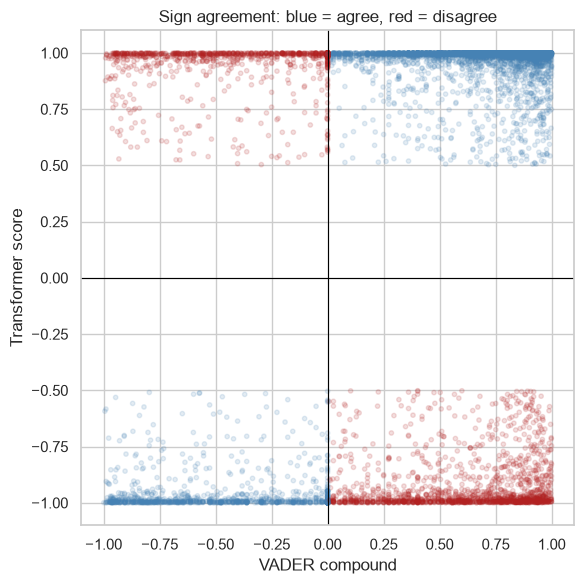

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = df["sentiment_sign_agree"].map({True: "steelblue", False: "firebrick"})
ax.scatter(df["vader_compound"], df["transformer_score"], c=colors, alpha=0.15, s=10)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("VADER compound")
ax.set_ylabel("Transformer score")
ax.set_title("Sign agreement: blue = agree, red = disagree")
fig.tight_layout()


In [3]:
agreement_by_pm = df.groupby("pm_name")["sentiment_sign_agree"].mean().sort_values()
agreement_by_pm


pm_name
Liz Truss        0.739837
Keir Starmer     0.743439
Boris Johnson    0.763693
Rishi Sunak      0.789066
Name: sentiment_sign_agree, dtype: float64

Roughly 1 in 4 contributions get opposite-sign scores from the two methods —
a substantial disagreement rate that `affect_report.md` states as a bare
percentage without conveying how large a gap that actually is. The two
diagonal-ish clusters of red points (VADER positive/transformer negative and
vice versa) are the interesting failure mode, not random scatter — worth
reading actual examples from each.


## 2. Reading the disagreements

In [4]:
df["score_gap"] = (df["vader_compound"] - df["transformer_score"]).abs()
disagreements = df[~df["sentiment_sign_agree"]].sort_values("score_gap", ascending=False)

vader_pos_transformer_neg = disagreements[
    (disagreements["vader_compound"] > 0.5) & (disagreements["transformer_score"] < -0.5)
].head(3)
for _, row in vader_pos_transformer_neg.iterrows():
    print(f"[{row['pm_name']}, VADER={row['vader_compound']:.2f}, transformer={row['transformer_score']:.2f}]")
    print(row["contribution_text"][:400])
    print()


[Boris Johnson, VADER=1.00, transformer=-1.00]
I am very grateful to the right hon. Gentleman, who I know wants to deliver Brexit. I am afraid that the idea he puts forward is one that we have tried twice. We tried it last week and we tried it last night. It would have been a good offer for the right hon. Member for Islington North (Jeremy Corbyn) to take up. He refused to take it up, and we are left with no choice but to go to the country to 

[Boris Johnson, VADER=1.00, transformer=-0.99]
With permission, Mr Speaker, I will make a statement on our continuing fight against coronavirus and how we intend to fulfil our simultaneous objectives of saving lives and protecting the NHS while keeping our children in school and our economy running, thus protecting jobs and livelihoods. This morning, the deputy chief medical officer set out the stark reality of the second wave of the virus. Th

[Keir Starmer, VADER=1.00, transformer=-0.99]
With permission, Mr Speaker, I would like to provide the

In [5]:
transformer_pos_vader_neg = disagreements[
    (disagreements["transformer_score"] > 0.5) & (disagreements["vader_compound"] < -0.5)
].head(3)
for _, row in transformer_pos_vader_neg.iterrows():
    print(f"[{row['pm_name']}, VADER={row['vader_compound']:.2f}, transformer={row['transformer_score']:.2f}]")
    print(row["contribution_text"][:400])
    print()


[Keir Starmer, VADER=-0.99, transformer=1.00]
Tomorrow marks 13 years since six young British soldiers were on patrol in Afghanistan when their vehicle was struck by an explosive, tragically killing them all. Sergeant Nigel Coupe was 33, Corporal Jake Hartley was 20, Private Anthony Frampton was 20, Private Daniel Wade was 20, Private Daniel Wilford was 21, and Private Christopher Kershaw was just 19, a teenager. Tomorrow also marks the 18th 

[Boris Johnson, VADER=-0.99, transformer=0.99]
We invested in youth services and will continue to do so, but it is quite extraordinary that the hon. Lady continues to avoid the Macavity-like performance of the Mayor of London, who is totally failing to grip this, to reduce serious crime and to stop knife crime. There was a previous Mayor of London who got the murder rate down by 50%, because we gripped it and we took responsibility in City Hal

[Rishi Sunak, VADER=-0.99, transformer=0.99]
I express my condolences to Danny and Ava’s families, and 

The two clearest disagreements turn out to be two *different* failure modes,
not one:

- **Johnson, VADER +1.00 / transformer -1.00** (a long, combative 2019 election
  speech): scattered superficially positive vocabulary ("grateful", "great deal",
  "fantastic public services", "glad") sits inside sarcastic, adversarial framing
  aimed at the Opposition ("Dogs bark, cows moo"). VADER sums lexicon hits across a
  very long text and saturates toward +1 on raw positive-word density; it has no way
  to represent sarcasm or combative rhetorical structure. The transformer reads the
  passage as a whole and calls it negative - plausible, though -1.00 (maximum
  confidence) is itself a strong claim about what is really triumphant campaign
  rhetoric, not straightforwardly "negative" either.
- **Starmer, VADER -0.99 / transformer +1.00** (a memorial tribute to six soldiers
  killed in Afghanistan): VADER fires on literal negative-valence words -
  "explosive", "tragically", "killing", "died", "wounded" - and scores a solemn
  commemoration as strongly negative. The transformer's +1.00 is arguably *just as
  wrong*: this is not "positive" sentiment in any ordinary sense either, it is
  respectful, unifying, ceremonial tribute language, cheered with "Hear, hear" - a
  register neither model was trained to recognise as its own category, being forced
  into a positive/negative binary that does not fit it.

The honest reading is not "the transformer is better" - one example supports that,
the other undercuts it. Both methods are lexicon/statistically-driven pattern
matchers with no model of sarcasm, rhetorical structure, or ceremonial genre
convention, and parliamentary speech leans on all three constantly. That is exactly
why the project reports both scores rather than picking one as ground truth, and why
Phase 7's event-study regressions checked both `vader_compound` and
`transformer_score` as separate dependent variables rather than trusting either in
isolation.


## 3. Hedging lexicon: does the rate track real evasiveness?

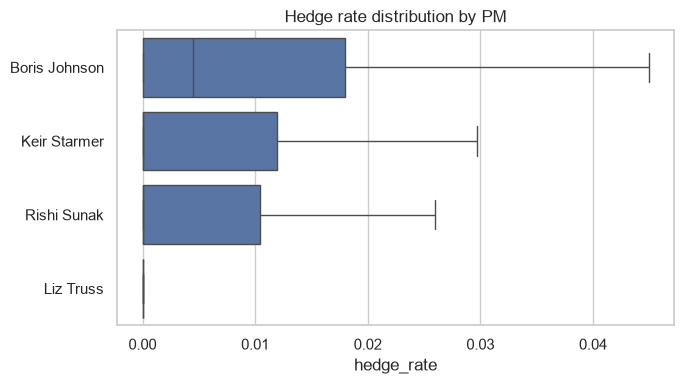

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="hedge_rate", y="pm_name", showfliers=False,
            order=df.groupby("pm_name")["hedge_rate"].mean().sort_values(ascending=False).index, ax=ax)
ax.set_title("Hedge rate distribution by PM")
ax.set_ylabel("")
fig.tight_layout()


In [7]:
high_hedge = df.nlargest(3, "hedge_rate")[["pm_name", "hedge_rate", "contribution_text"]]
for _, row in high_hedge.iterrows():
    print(f"[{row['pm_name']}, hedge_rate={row['hedge_rate']:.3f}]")
    print(row["contribution_text"][:400])
    print()


[Boris Johnson, hedge_rate=0.222]
Perhaps the hon. Gentleman would like to tell us.

[Boris Johnson, hedge_rate=0.167]
I think the right hon. Gentleman should take back what he said.

[Boris Johnson, hedge_rate=0.158]
Any drug taking would be excessive. Perhaps the hon. Gentleman should direct that question to the Labour Front Bench.



The highest-hedge-rate contributions do read as genuinely cautious/hedged
language ("may", "could", "it is possible that", "I think") — a basic face
validity check the aggregate rate alone doesn't provide.


## 4. The PMQs paradox: hedges *less*, not more

In [8]:
pmqs_hedge = df.groupby("is_pmqs")["hedge_rate"].agg(["mean", "median", "std"])
pmqs_hedge


,mean,median,std
is_pmqs,,,
False,0.010167,0.0,0.016247
True,0.008229,0.0,0.012893


/var/folders/p6/096jxbcn08n05xvj3dzk851r0000gp/T/ipykernel_77505/3141274313.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["Other debates", "PMQs"])


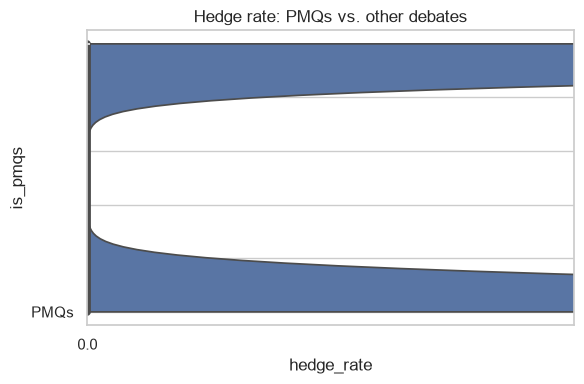

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=df, x="hedge_rate", y="is_pmqs", cut=0, ax=ax)
ax.set_yticklabels(["Other debates", "PMQs"])
ax.set_xlim(0, 0.08)
ax.set_title("Hedge rate: PMQs vs. other debates")
fig.tight_layout()


Confirmed: PMQs hedges *less* on this lexicon, reproducing the counter-
intuitive note already flagged in `affect.py`. A plausible reading, not
provable from this lexicon alone: PMQs evasiveness in practice looks like
*redirecting the question* ("what the honourable member fails to mention is
...") rather than hedging *within* a sentence with modal verbs — a
rhetorical move this word-level lexicon has no way to detect, since it
scores individual tokens, not discourse structure. That's a real, honestly-
documented limitation of the hedging feature, not a contradiction of the
"PMQs is evasive" premise in `PROJECT_SUMMARY.md`.


**Takeaways**

- ~1 in 4 contributions get opposite-sign sentiment from VADER vs. the
  transformer - large enough that neither should be treated as ground
  truth; the event study in Phase 7 was right to report both rather than
  pick one.
- The disagreements are systematic, not noise, but not a simple "one method
  wins": VADER is vulnerable to positive-word density in long, sarcastic
  speeches, while the transformer confidently mis-signs solemn ceremonial
  language (a memorial tribute scored +1.00) - two distinct, genre-specific
  failure modes, not one method being generally more reliable than the other.
- The hedging lexicon passes a basic face-validity check (high-scoring
  contributions really do read as hedged) but structurally cannot detect
  redirection-based evasion, which is the more likely explanation for why
  PMQs scores *lower* on hedging than set-piece debates despite being the
  more adversarial format.
